In [43]:
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "components").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "components").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))



from components.fcm import fcm_initialize
from components.models import ANFISAdvanced


In [44]:
# ---------------------------
# 1) Prepare make_circles data
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HAS_CUDA = torch.cuda.is_available()
if HAS_CUDA:
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def build_circles(n_samples=2000, noise=0.05):
    X, y = make_circles(n_samples=n_samples, factor=0.4, noise=noise, random_state=SEED)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)
    return X_scaled, y.astype(np.int64)


X, y = build_circles()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

In [45]:
# ---------------------------
# 5) Training loop
# ---------------------------
device = torch.device("cuda" if HAS_CUDA else "cpu")

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

K = 6
centers_init, spreads_init = fcm_initialize(X_train, K)
s_mode_choice = "alpha_beta"
model = ANFISAdvanced(centers_init, spreads_init, s_mode=s_mode_choice).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 1200
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 200 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_prob = torch.sigmoid(model(X_train_tensor))
            test_prob = torch.sigmoid(model(X_test_tensor))
            train_rmse = torch.sqrt(torch.mean((train_prob - y_train_tensor) ** 2)).item()
            test_rmse = torch.sqrt(torch.mean((test_prob - y_test_tensor) ** 2)).item()
        print(
            f"Epoch {epoch:04d}/{n_epochs}  Loss {loss.item():.4f}  "
            f"Train RMSE {train_rmse:.4f}  Test RMSE {test_rmse:.4f}"
        )

if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    final_train_logits = model(X_train_tensor)
    final_test_logits = model(X_test_tensor)
    final_train_prob = torch.sigmoid(final_train_logits).cpu().numpy().reshape(-1)
    final_test_prob = torch.sigmoid(final_test_logits).cpu().numpy().reshape(-1)

train_rmse = np.sqrt(np.mean((final_train_prob - y_train) ** 2))
test_rmse = np.sqrt(np.mean((final_test_prob - y_test) ** 2))
train_acc = np.mean((final_train_prob > 0.5) == y_train)
test_acc = np.mean((final_test_prob > 0.5) == y_test)

print("\nFinal Results:")
print(f"Mode: {s_mode_choice}")
print(f"Train RMSE: {train_rmse:.4f}  |  Train Acc: {train_acc:.3f}")
print(f"Test  RMSE: {test_rmse:.4f}  |  Test  Acc: {test_acc:.3f}")



Epoch 0001/1200  Loss 0.6974  Train RMSE 0.5020  Test RMSE 0.5019
Epoch 0200/1200  Loss 0.6279  Train RMSE 0.4662  Test RMSE 0.4674
Epoch 0400/1200  Loss 0.4635  Train RMSE 0.3731  Test RMSE 0.3744
Epoch 0600/1200  Loss 0.2939  Train RMSE 0.2614  Test RMSE 0.2634
Epoch 0800/1200  Loss 0.1842  Train RMSE 0.1774  Test RMSE 0.1792
Epoch 1000/1200  Loss 0.1342  Train RMSE 0.1359  Test RMSE 0.1372
Epoch 1200/1200  Loss 0.1060  Train RMSE 0.1116  Test RMSE 0.1124

Final Results:
Mode: alpha_beta
Train RMSE: 0.1116  |  Train Acc: 1.000
Test  RMSE: 0.1124  |  Test  Acc: 1.000


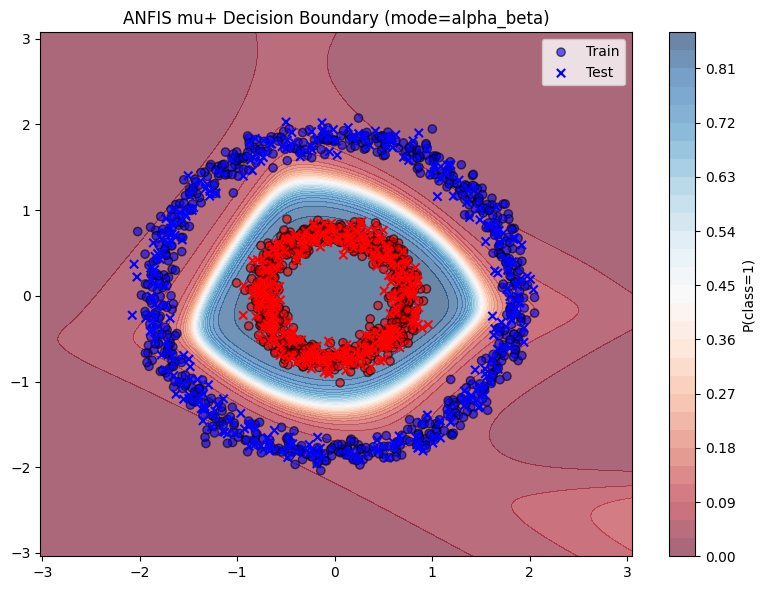

In [46]:
# ---------------------------
# 6) Decision boundary visualization
# ---------------------------
xx, yy = np.meshgrid(
    np.linspace(X_train[:, 0].min() - 1.0, X_train[:, 0].max() + 1.0, 250),
    np.linspace(X_train[:, 1].min() - 1.0, X_train[:, 1].max() + 1.0, 250),
)
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_tensor = torch.from_numpy(grid).to(device)
with torch.no_grad():
    grid_prob = torch.sigmoid(model(grid_tensor)).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, grid_prob, levels=30, cmap="RdBu", alpha=0.6)
plt.colorbar(label="P(class=1)")
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap="bwr",
    edgecolor="k",
    alpha=0.6,
    label="Train",
)
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="bwr",
    marker="x",
    label="Test",
)
plt.title(f"ANFIS mu+ Decision Boundary (mode={s_mode_choice})")
plt.legend()
plt.tight_layout()
plt.show()

